In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import xgboost
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import seaborn as sns

In [2]:
def median_imputation(df):
    for col in df.columns:
        if col == 'grid_id' or col == 'date':
            continue
        df[col] = df[col].fillna(df[col].median())
    return df

In [3]:
train_data = pd.read_csv('C:\GaTech\MS-CSE\ISYE 6740\WiFOP\\notebooks\\final_datasets\Fire_Train_data.csv', sep=',')
test_data = pd.read_csv('C:\GaTech\MS-CSE\ISYE 6740\WiFOP\\notebooks\\final_datasets\Fire_test.csv', sep=',')

In [4]:
train_labels = pd.read_csv('C:\GaTech\MS-CSE\ISYE 6740\WiFOP\\notebooks\\final_datasets\\fire_train_labels.csv', sep=',')
test_labels = pd.read_csv('C:\GaTech\MS-CSE\ISYE 6740\WiFOP\\notebooks\\final_datasets\\fire_test_labels.csv', sep=',')

In [5]:
X_train, X_val, y_train, y_val = train_test_split(train_data, train_labels, stratify=train_labels, random_state=42, test_size=0.1)

In [6]:
X_train, X_val, X_test = median_imputation(X_train), median_imputation(X_val), median_imputation(test_data)

In [7]:
xgb = xgboost.XGBClassifier(device='cuda', n_estimators=400, random_state=42)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
feature_columns = pd.DataFrame({'Features': X_train.columns, 'Importances': xgb.feature_importances_}).sort_values(by=['Importances'], ascending=False)

In [9]:
top_k = list(feature_columns.iloc[:20, 0])
X_train_selected = X_train[top_k]
X_test_selected = X_test[top_k]
X_val_selected = X_val[top_k]

In [10]:
top_k

['ndvi_7d_mean',
 'fires_last_14d',
 'fuel_moisture_proxy',
 'ndvi_spatial_mean_10km',
 'fires_last_7d',
 'neighbor_fires_last_14d',
 'ndvi',
 'RH2M_spatial_mean_10km',
 'RH2M_3d_min',
 'neighbor_fires_last_7d',
 'PS',
 'dry_windy',
 'RH2M',
 'WS10M_spatial_mean_10km',
 'pct_Shrub/Scrub',
 'WS10M_3d_max',
 'PRECTOT_7d_sum',
 'pct_Barren Land (Rock/Sand/Clay)',
 'vpd_spatial_mean_10km',
 'vpd_proxy']

In [11]:
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)
X_val_selected_scaled = scaler.transform(X_val_selected)

In [12]:
class Model(tf.keras.Model):
    def __init__(self, input_dimension, neurons, num_classes):
        super().__init__()

        #Convolutional Layer
        self.conv1 = tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')
        self.batch1 = tf.keras.layers.BatchNormalization()
        self.maxpool1 = tf.keras.layers.MaxPool1D(3)

        #Convolutional Layer
        self.conv2 = tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')
        self.batch2 = tf.keras.layers.BatchNormalization()
        self.maxpool2 = tf.keras.layers.MaxPool1D(3)

        #Flatten Layer
        self.flatten = tf.keras.layers.Flatten()

        #Dense Layer (hidden layer)
        self.dense = tf.keras.layers.Dense(units=neurons, activation='relu')
        self.batch3 = tf.keras.layers.BatchNormalization()
        self.output_layer = tf.keras.layers.Dense(units=num_classes, activation='sigmoid')

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.batch1(x)
        x = self.maxpool1(x)

        x = self.conv2(x)
        x = self.batch2(x)
        x = self.maxpool2(x)

        x = self.flatten(x)
        x = self.dense(x)
        x = self.batch3(x)
        output = self.output_layer(x)

        return output


In [13]:
cb = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

In [14]:
n_features = len(top_k)
model = Model(input_dimension=n_features, neurons=128, num_classes=1)
model.build(input_shape=(None, n_features, 1))
model.compile(loss=tf.keras.losses.BinaryCrossentropy(), optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), metrics=['accuracy'])

In [15]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             multiple                  128       
                                                                 
 batch_normalization (BatchN  multiple                 128       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  multiple                 0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           multiple                  12416     
                                                                 
 batch_normalization_1 (Batc  multiple                 512       
 hNormalization)                                                 
                                                             

In [16]:
X_train_cnn = X_train_selected_scaled.reshape(-1, n_features, 1)
X_test_cnn = X_test_selected_scaled.reshape(-1, n_features, 1)
X_val_cnn = X_val_selected_scaled.reshape(-1, n_features, 1)

In [17]:
history = model.fit(X_train_cnn, y_train, batch_size=512, epochs=20, verbose=2, validation_data=(X_val_cnn, y_val), callbacks=cb)

Epoch 1/20
10874/10874 - 52s - loss: 0.0187 - accuracy: 0.9966 - val_loss: 0.0137 - val_accuracy: 0.9976 - lr: 0.0010 - 52s/epoch - 5ms/step
Epoch 2/20
10874/10874 - 40s - loss: 0.0135 - accuracy: 0.9975 - val_loss: 0.0136 - val_accuracy: 0.9976 - lr: 0.0010 - 40s/epoch - 4ms/step
Epoch 3/20
10874/10874 - 41s - loss: 0.0133 - accuracy: 0.9976 - val_loss: 0.0136 - val_accuracy: 0.9976 - lr: 0.0010 - 41s/epoch - 4ms/step
Epoch 4/20
10874/10874 - 38s - loss: 0.0133 - accuracy: 0.9976 - val_loss: 0.0135 - val_accuracy: 0.9976 - lr: 0.0010 - 38s/epoch - 4ms/step
Epoch 5/20
10874/10874 - 38s - loss: 0.0132 - accuracy: 0.9976 - val_loss: 0.0134 - val_accuracy: 0.9976 - lr: 0.0010 - 38s/epoch - 3ms/step
Epoch 6/20
10874/10874 - 41s - loss: 0.0132 - accuracy: 0.9976 - val_loss: 0.0134 - val_accuracy: 0.9976 - lr: 0.0010 - 41s/epoch - 4ms/step
Epoch 7/20
10874/10874 - 41s - loss: 0.0132 - accuracy: 0.9976 - val_loss: 0.0133 - val_accuracy: 0.9976 - lr: 0.0010 - 41s/epoch - 4ms/step
Epoch 8/20
10

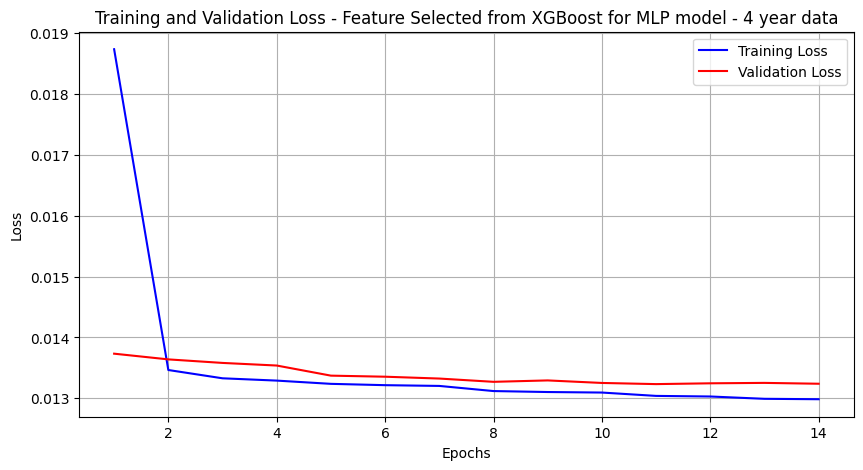

In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history.history['loss'], 'b', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'r', label='Validation Loss')
plt.title('Training and Validation Loss - Feature Selected from XGBoost for CNN model - 4 year data')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

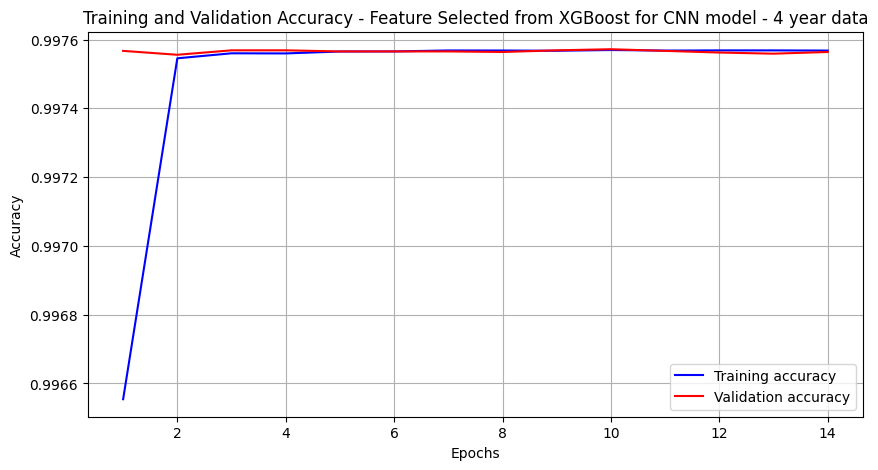

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, history.history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy - Feature Selected from XGBoost for CNN model - 4 year data')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
predictions = model.predict(X_test_cnn)
y_prob = predictions.ravel()
y_pred = (y_prob >= 0.1).astype(int) 

64436/64436 [==============================] - 66s 1ms/step


In [21]:
print(precision_score(test_labels, y_pred, average='weighted', zero_division=0))
print(recall_score(test_labels, y_pred, average='weighted', zero_division=0))
print(f1_score(test_labels, y_pred, average='weighted', zero_division=0))

0.994932839346354
0.9946831160441568
0.9948065922160843


In [22]:
clr = classification_report(test_labels, y_pred, zero_division=0.0, output_dict=True)

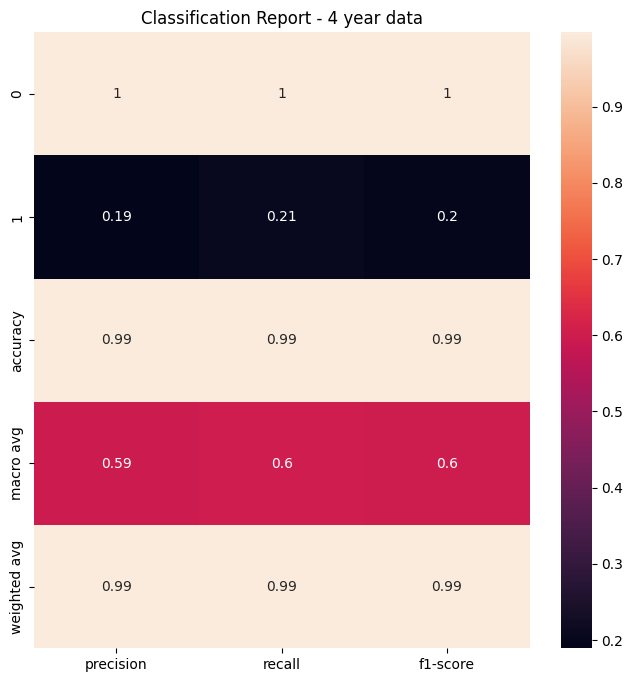

In [23]:
df_clr = pd.DataFrame(clr).transpose()
plt.figure(figsize=(8,8))
sns.heatmap(df_clr[['precision', 'recall', 'f1-score']], annot=True)
plt.title('Classification Report - 4 year data')
plt.show()

In [24]:
print(average_precision_score(test_labels, y_pred))

0.041779887733148835


In [25]:
print(roc_auc_score(test_labels, y_pred))

0.6024104493349648


In [26]:
for t in [0.65, 0.6, 0.50, 0.30, 0.20, 0.10, 0.05]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(test_labels, y_pred, digits=3))



Threshold = 0.65
              precision    recall  f1-score   support

           0      0.997     1.000     0.998   2055406
           1      0.900     0.001     0.003      6516

    accuracy                          0.997   2061922
   macro avg      0.948     0.501     0.501   2061922
weighted avg      0.997     0.997     0.995   2061922


Threshold = 0.6
              precision    recall  f1-score   support

           0      0.997     1.000     0.998   2055406
           1      0.773     0.003     0.005      6516

    accuracy                          0.997   2061922
   macro avg      0.885     0.501     0.502   2061922
weighted avg      0.996     0.997     0.995   2061922


Threshold = 0.5
              precision    recall  f1-score   support

           0      0.997     1.000     0.998   2055406
           1      0.615     0.007     0.015      6516

    accuracy                          0.997   2061922
   macro avg      0.806     0.504     0.506   2061922
weighted avg      0.99